# Introduction to Exploratory Data Analysis (EDA)

**"Exploratory data analysis (EDA) is a critical first step in analyzing the data [...]. Loosely speaking, any method of looking at data that does not include formal statistical modeling and inference falls under the term exploratory data analysis."**  
— Seltman, H.J. (2018). Experimental Design and Analysis, Chapter 4. (Term goes back to Tukey, J.W., 1977.)

## Objectives of EDA
- Enable unexpected discoveries in the data
- Suggest hypotheses about the causes of observed phenomena
- Assess assumptions on which statistical inference will be based
- Support the selection of appropriate statistical tools and techniques
- Check data quality (missing values, duplicates, implausible values) before any modeling

## Systematics of EDA Methods

| | Non-Graphical | Graphical |
|---|---|---|
| **Univariate** | mean, median, std, skewness | histogram, box plot, bar chart |
| **Multivariate** | correlation, covariance | scatter plot, scatter matrix, heatmap |

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Seaborn theme
import seaborn as sns
sns.set_theme(style='whitegrid')

## Anscombe's Quartet

Anscombe's quartet consists of **four datasets** that have nearly identical simple statistical properties (mean, variance, correlation, regression line) yet look very different when plotted. This demonstrates the importance of always visualizing your data.

**Key message:** Summary statistics alone can be misleading — always complement non-graphical with graphical EDA methods.

In [2]:
# Anscombe's quartet data
anscombe = sns.load_dataset('anscombe')
print('Summary statistics per dataset:')
anscombe.groupby('dataset').agg(
    x_mean=('x', 'mean'),
    y_mean=('y', 'mean'),
    x_var=('x', 'var'),
    y_var=('y', 'var'),
    corr=('x', lambda x: x.corr(anscombe.loc[x.index, 'y']))
).round(2)

Summary statistics per dataset:


,x_mean,y_mean,x_var,y_var,corr
dataset,,,,,
I,9.0,7.5,11.0,4.13,0.82
II,9.0,7.5,11.0,4.13,0.82
III,9.0,7.5,11.0,4.12,0.82
IV,9.0,7.5,11.0,4.12,0.82


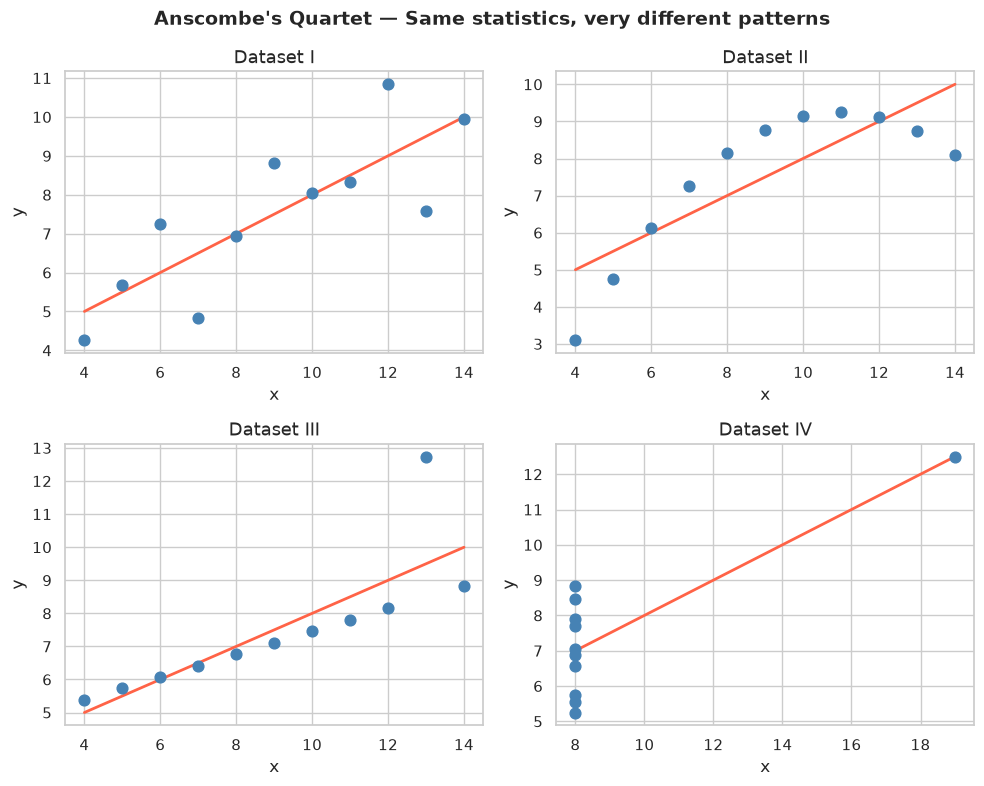

In [3]:
# Plot all four datasets
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
axes = axes.flatten()

for i, (dataset, group) in enumerate(anscombe.groupby('dataset')):
    ax = axes[i]
    ax.scatter(group['x'], group['y'], color='steelblue', s=60, zorder=3)
    # Regression line
    m, b = np.polyfit(group['x'], group['y'], 1)
    x_line = np.linspace(group['x'].min(), group['x'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)
    ax.set_title(f'Dataset {dataset}', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.suptitle("Anscombe's Quartet — Same statistics, very different patterns", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## The Datasaurus Dozen

A modern variant of Anscombe's quartet (Matejka & Fitzmaurice, 2017): 12 datasets with identical summary statistics but wildly different shapes — including a dinosaur!

In [4]:
# Install datasetsaurus if not available: pip install datasetsaurus
try:
    import urllib.request, io
    url = 'https://raw.githubusercontent.com/jumpingrivers/datasauRus/main/inst/extdata/datasaurus_dozen.tsv'
    # Use local fallback: just demonstrate the concept with anscombe
    print('Datasaurus Dozen: 13 datasets with (nearly) identical means, stds, and correlations.')
    print('See: https://www.autodesk.com/research/publications/same-stats-different-graphs')
    print()
    print('Key takeaway: ALWAYS visualize your data in addition to computing summary statistics!')
except Exception as e:
    print(e)

Datasaurus Dozen: 13 datasets with (nearly) identical means, stds, and correlations.
See: https://www.autodesk.com/research/publications/same-stats-different-graphs

Key takeaway: ALWAYS visualize your data in addition to computing summary statistics!


## Data Quality Checks

Before any analysis, always inspect the data for quality issues.

In [5]:
# Load apartment data
df = pd.read_csv('../data/apartments_data_enriched_cleaned.csv', )
print('Shape:', df.shape)
print()
df.head(3)

Shape: (774, 17)



,Unnamed: 0,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income
0,0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49.0,0,1441.0,29.41,12286,1221.272366,5053.0,24.841283,65362.042683
1,1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111.0,0,2600.0,23.42,12286,1221.272366,5053.0,24.841283,65362.042683
2,2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58.0,0,1490.0,25.69,12286,1221.272366,5053.0,24.841283,65362.042683


In [6]:
# Data types
print('Data types:')
print(df.dtypes)
print()
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print()
# Duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

Data types:
Unnamed: 0               int64
web-scraper-order          str
address_raw                str
lat                    float64
lon                    float64
bfs_number               int64
bfs_name                   str
rooms                  float64
area                   float64
luxurious                int64
price                  float64
price_per_m2           float64
pop                      int64
pop_dens               float64
emp                    float64
frg_pct                float64
mean_taxable_income    float64
dtype: object

Missing values per column:
Unnamed: 0             0
web-scraper-order      0
address_raw            0
lat                    0
lon                    0
bfs_number             0
bfs_name               0
rooms                  0
area                   0
luxurious              0
price                  0
price_per_m2           0
pop                    0
pop_dens               0
emp                    0
frg_pct                0
mean_taxable_income

## Jupyter notebook --footer info--
(please always provide this at the end of each notebook)

In [7]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('------------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('------------------------------------')

------------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-01 07:16:33
Python Version: 3.11.16
------------------------------------
